<a href="https://colab.research.google.com/github/kishorekumarwebdev/GenAI/blob/main/Simple%20GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.08MB/s]


Epoch [1/50] | D Loss: 0.4897 | G Loss: 1.4663
Epoch [2/50] | D Loss: 1.4988 | G Loss: 0.8855
Epoch [3/50] | D Loss: 1.0334 | G Loss: 1.0139
Epoch [4/50] | D Loss: 0.8910 | G Loss: 1.0515
Epoch [5/50] | D Loss: 1.2099 | G Loss: 0.8864
Epoch [6/50] | D Loss: 1.2236 | G Loss: 0.9051
Epoch [7/50] | D Loss: 1.2185 | G Loss: 0.8614
Epoch [8/50] | D Loss: 1.4199 | G Loss: 0.8817
Epoch [9/50] | D Loss: 1.1371 | G Loss: 0.8853
Epoch [10/50] | D Loss: 1.5515 | G Loss: 0.8402
Epoch [11/50] | D Loss: 0.7920 | G Loss: 1.2571
Epoch [12/50] | D Loss: 1.2803 | G Loss: 0.9269
Epoch [13/50] | D Loss: 1.4004 | G Loss: 0.7301
Epoch [14/50] | D Loss: 1.2291 | G Loss: 0.9112
Epoch [15/50] | D Loss: 1.3813 | G Loss: 0.8363
Epoch [16/50] | D Loss: 0.8236 | G Loss: 1.5206
Epoch [17/50] | D Loss: 0.6650 | G Loss: 1.7836
Epoch [18/50] | D Loss: 0.9572 | G Loss: 1.4137
Epoch [19/50] | D Loss: 0.6969 | G Loss: 1.6710
Epoch [20/50] | D Loss: 1.2484 | G Loss: 0.7816
Epoch [21/50] | D Loss: 0.9469 | G Loss: 1.3010
E

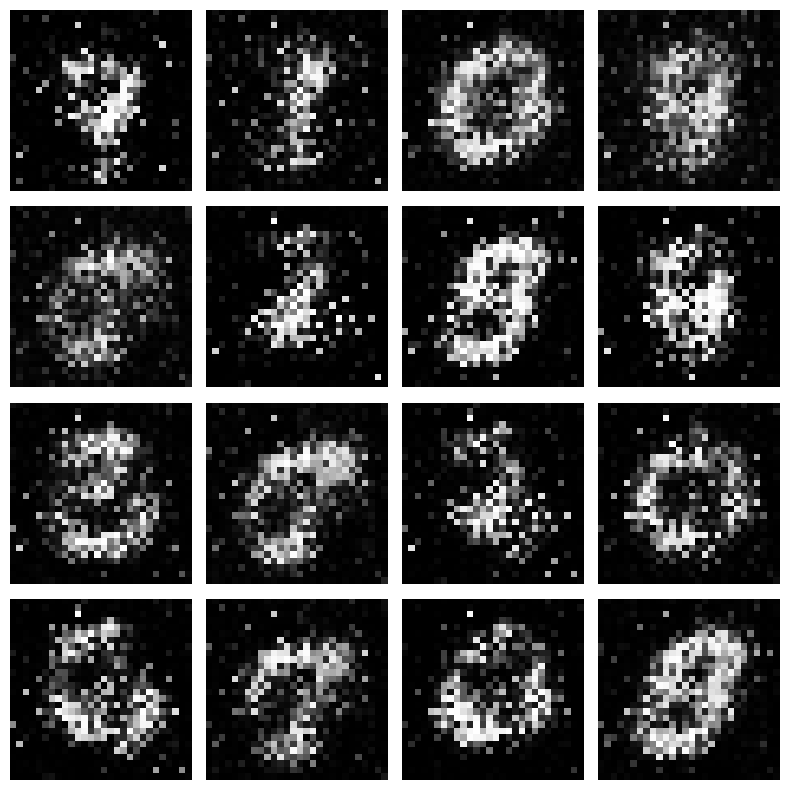

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Generator Model
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST Dataset
dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Initialize Models
noise_dim = 100
generator = Generator(noise_dim).to(device)
discriminator = Discriminator().to(device)

# Loss Function and Optimizers
criterion = nn.BCELoss()

optim_G = optim.Adam(generator.parameters(), lr=0.0002)
optim_D = optim.Adam(discriminator.parameters(), lr=0.0002)

# Training
epochs = 50

for epoch in range(epochs):
    for real_images, _ in loader:

        batch_size = real_images.size(0)

        real_images = real_images.view(batch_size, -1).to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(z)

        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        optim_D.zero_grad()
        d_loss.backward()
        optim_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(z)

        outputs = discriminator(fake_images)

        g_loss = criterion(outputs, real_labels)

        optim_G.zero_grad()
        g_loss.backward()
        optim_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# Generate Images
generator.eval()

z = torch.randn(16, noise_dim).to(device)

with torch.no_grad():
    fake_images = generator(z).view(-1, 1, 28, 28)

fake_images = fake_images.cpu()

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()